<a href="https://colab.research.google.com/github/sparkiqai-codes/sparky_ismrait27/blob/main/Multi_agent_based_Industrial_Safety_Risk_Prediction_with_State_Transition_with_fine_tuned_VLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

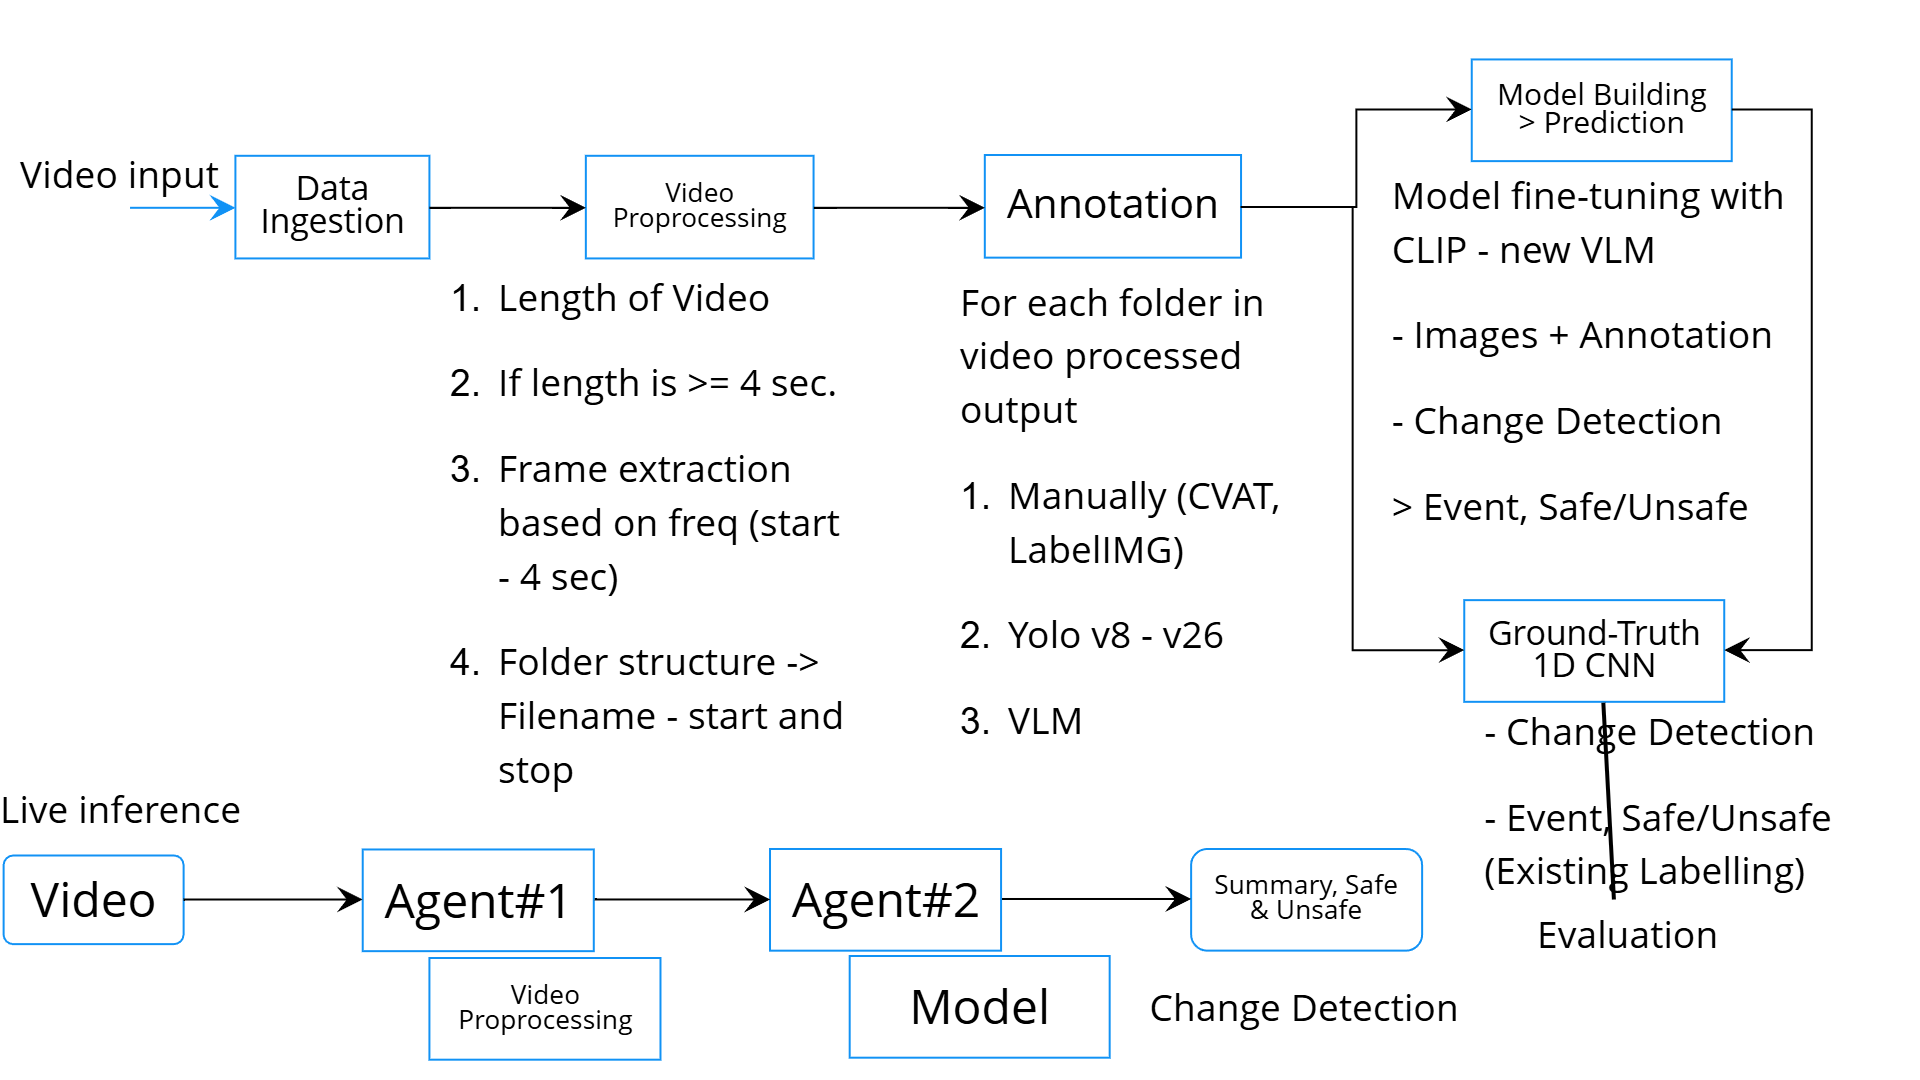

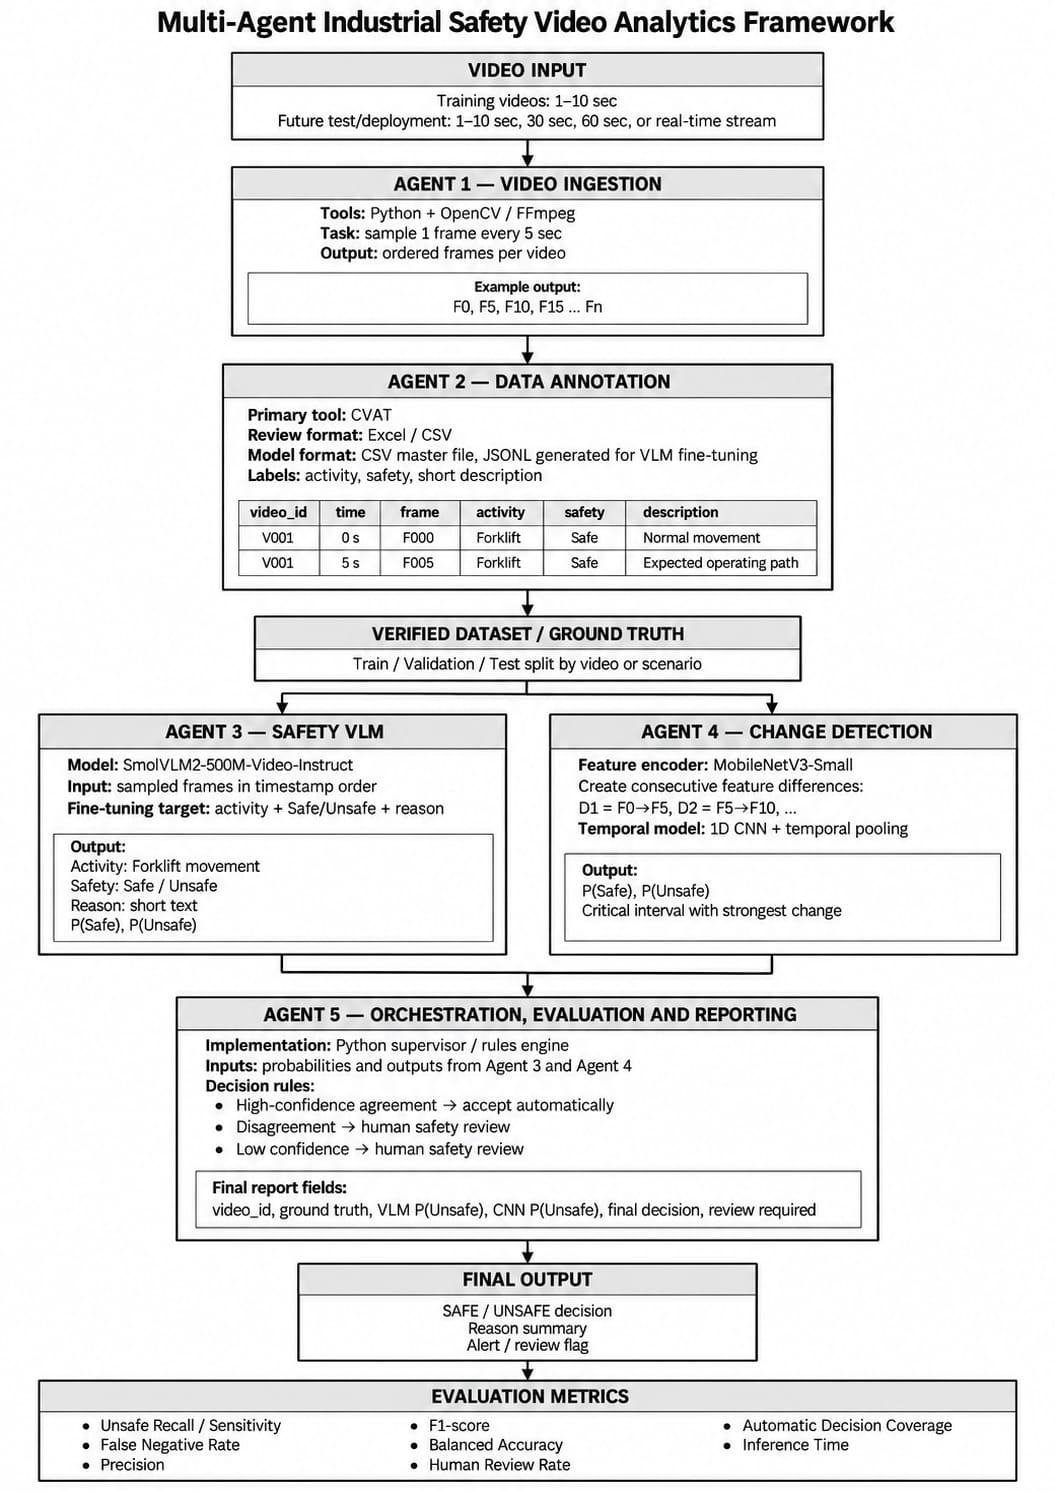

In [1]:
!rm -rf sparky_ismrait27
!git clone https://github.com/sparkiqai-codes/sparky_ismrait27.git

Cloning into 'sparky_ismrait27'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 12 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 997.28 KiB | 16.35 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [2]:
import os

# Ensure we change to the expected root directory of the cloned repository
expected_repo_path = '/content/sparky_ismrait27'

if os.path.exists(expected_repo_path):
    os.chdir(expected_repo_path)
    print(f"Successfully changed directory to: {os.getcwd()}")
else:
    print(f"Error: '{expected_repo_path}' directory not found after git clone. Please check the git clone command output for errors.")
    print("Current directory contents of /content:")
    !ls -F /content

Successfully changed directory to: /content/sparky_ismrait27


In [3]:
import os

# Configure Git user
!git config --global user.email "contactus@sparkiqai.co.in"
!git config --global user.name "sparkiqai-codes"

# Clean up and re-initialize git repository
# This handles cases where git clone might have left a partial or problematic .git
if os.path.exists('.git'):
    print("Removing existing .git directory...")
    !rm -rf .git
print("Initializing new git repository...")
!git init

# Add README.md
!git add README.md

# Commit the README.md
!git commit -m "Initial commit: Add README.md"

# Remove existing remote 'origin' if it exists before adding
# The '2>/dev/null || true' suppresses errors if origin doesn't exist.
!git remote rm origin 2>/dev/null || true
print("Setting remote origin...")
!git remote add origin https://github.com/sparkiqai-codes/sparky_ismrait27.git

# Set the branch name to main
!git branch -M main

print("Git repository configured and initial commit made.")
print("You are ready to push to the remote repository.")

Removing existing .git directory...
Initializing new git repository...
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/sparky_ismrait27/.git/
[master (root-commit) 5709afb] Initial commit: Add README.md
 1 file changed, 1 insertion(+)
 create mode 100644 README.md
Setting remote origin...
Git repository configured and initial commit made.
You are ready to push to the remote repository.


## Model and Tool Development

### Data Ingestion
Download the dataset from the online

In [4]:
!wget --user-agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64)" -O dataset.zip "https://data.mendeley.com/public-api/zip/xjmtb22pff/download/1"

--2026-09-28 01:56:22--  https://data.mendeley.com/public-api/zip/xjmtb22pff/download/1
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/xjmtb22pff-1.zip?X-Amz-Security-Token=IQoJb3JpZ2luX2VjEGIaCWV1LXdlc3QtMSJGMEQCIDzmE4oFp3zsF87Bcjfx5s2YLhoWGwyRO7Y13XNvDqDvAiBnjc%2FwKiFH53UBRBHULytP1NCn0JgELLCQpweu95fckyqMBQgqEAQaDDM2NzE0NzM4MzgyNSIMoz2N6KKKK8q1XsrjKukErD8iksStbCwe6C6Ovhf0qtBjxXw%2FoEo1GZ2JQ7ePRmbsak0qvLR1K5RZ9WAkt5XpV0ZfSqKrZJLCkfVYBNm9IuavjMNvhyKGIJo5bbtcPWkv1VAYawlGnOuVatUMIyQMW7s5G6LatqbuffVVpmM5Trl5souEuYzN7mDJAjuJDp5plLUW6m4%2B2ISE2YtkSPTk29ops5pydrCYUOy%2BdKbwuJuyqLuE65wcCRvfM%2F2R8Z7TEkL4jJBsPiY6zLHSznxiE8DejHbWPkn7d7SbHYFa5REdmLhzonnsqCVrnMXR96PTrzwMDtkkMMLm3XsOrPD780BOWOwdVy3y6T1FROwuflx5Eu8hH6NcvBeTYCuyxyZNtVuUohTl1g01x99T87QAz%2B

In [5]:
import zipfile, os
os.makedirs("./sparky_ismrait27/mendeley_dataset", exist_ok=True)
with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("./sparky_ismrait27/mendeley_dataset")
print(os.listdir("./sparky_ismrait27/mendeley_dataset"))

['Video Dataset for Safe and Unsafe Behaviours']


## Video processing

In [9]:
import os
import cv2
import shutil


source_path = "./sparky_ismrait27/mendeley_dataset/Video Dataset for Safe and Unsafe Behaviours/Safe and Unsafe Behaviours Dataset/train"

output_path = "./sparky_ismrait27/mendeley_dataset/train_4sec_plus"

os.makedirs(output_path, exist_ok=True)

total = 0
kept = 0
discarded = 0

for root, dirs, files in os.walk(source_path):

    for filename in files:

        if not filename.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
            continue

        total += 1

        video_path = os.path.join(root, filename)

        cap = cv2.VideoCapture(video_path)

        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)

        duration = frame_count / fps if fps > 0 else 0

        cap.release()

        if duration >= 4:

            relative_path = os.path.relpath(root, source_path)
            destination_folder = os.path.join(output_path, relative_path)

            os.makedirs(destination_folder, exist_ok=True)

            shutil.copy2(
                video_path,
                os.path.join(destination_folder, filename)
            )

            kept += 1
            print(f"KEPT     {filename} → {duration:.2f} sec")

        else:
            discarded += 1
            print(f"DISCARDED {filename} → {duration:.2f} sec")

print("\n========== SUMMARY ==========")
print("Total videos:", total)
print("Videos >= 4 sec:", kept)
print("Videos < 4 sec:", discarded)
print("Output folder:", output_path)

KEPT     4_tr38.mp4 → 12.16 sec
KEPT     4_tr45.mp4 → 7.05 sec
KEPT     4_tr14.mp4 → 10.43 sec
KEPT     4_tr27.mp4 → 10.03 sec
KEPT     4_tr49.mp4 → 6.96 sec
KEPT     4_tr37.mp4 → 12.20 sec
KEPT     4_tr43.mp4 → 13.90 sec
KEPT     4_tr50.mp4 → 6.92 sec
KEPT     4_tr32.mp4 → 7.05 sec
KEPT     4_tr48.mp4 → 15.64 sec
KEPT     4_tr25.mp4 → 8.01 sec
KEPT     4_tr21.mp4 → 8.98 sec
KEPT     4_tr39.mp4 → 12.16 sec
KEPT     4_tr26.mp4 → 6.04 sec
KEPT     4_tr10.mp4 → 10.44 sec
KEPT     4_tr3.mp4 → 4.18 sec
KEPT     4_tr19.mp4 → 8.01 sec
KEPT     4_tr17.mp4 → 9.02 sec
KEPT     4_tr42.mp4 → 8.33 sec
KEPT     4_tr40.mp4 → 8.37 sec
KEPT     4_tr47.mp4 → 15.64 sec
KEPT     4_tr46.mp4 → 10.99 sec
KEPT     4_tr31.mp4 → 4.03 sec
KEPT     4_tr36.mp4 → 12.20 sec
KEPT     4_tr2.mp4 → 8.48 sec
KEPT     4_tr16.mp4 → 7.80 sec
KEPT     4_tr18.mp4 → 11.04 sec
KEPT     4_tr24.mp4 → 8.90 sec
KEPT     4_tr9.mp4 → 6.92 sec
KEPT     4_tr22.mp4 → 11.04 sec
KEPT     4_tr7.mp4 → 6.96 sec
KEPT     4_tr30.mp4 → 9.63 sec

## EDA of Video length

In [10]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt


DATASET_PATH = "./sparky_ismrait27/mendeley_dataset/train_4sec_plus"

data = []


for root, dirs, files in os.walk(DATASET_PATH):
    for filename in files:

        if not filename.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
            continue

        video_path = os.path.join(root, filename)

        cap = cv2.VideoCapture(video_path)

        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)

        duration = frame_count / fps if fps > 0 else 0

        cap.release()

        data.append({
            "filename": filename,
            "duration_sec": duration,
            "fps": fps,
            "frame_count": frame_count
        })


df = pd.DataFrame(data)

print("EDA completed!")
print("Total videos:", len(df))

df.head()

EDA completed!
Total videos: 535


,filename,duration_sec,fps,frame_count
0,4_tr38.mp4,12.162706,24.830000,302.0
1,4_tr45.mp4,7.048984,25.110000,177.0
2,4_tr14.mp4,10.428375,24.931976,260.0
3,4_tr27.mp4,10.028192,24.830000,249.0
4,4_tr49.mp4,6.960000,25.000000,174.0


In [11]:
print("========== VIDEO LENGTH EDA ==========")

print(f"Total videos       : {len(df)}")
print(f"Minimum duration   : {df['duration_sec'].min():.2f} sec")
print(f"Maximum duration   : {df['duration_sec'].max():.2f} sec")
print(f"Mean duration      : {df['duration_sec'].mean():.2f} sec")
print(f"Median duration    : {df['duration_sec'].median():.2f} sec")
print(f"Std deviation      : {df['duration_sec'].std():.2f} sec")

print("\nDuration statistics:")
print(df["duration_sec"].describe())

========== VIDEO LENGTH EDA ==========
Total videos       : 535
Minimum duration   : 4.00 sec
Maximum duration   : 20.84 sec
Mean duration      : 8.52 sec
Median duration    : 7.97 sec
Std deviation      : 3.24 sec

Duration statistics:
count    535.000000
mean       8.524176
std        3.236234
min        4.000000
25%        6.038126
50%        7.971303
75%       10.449548
max       20.838323
Name: duration_sec, dtype: float64


In [12]:
import os
import cv2

# Input folder
INPUT_PATH = "./sparky_ismrait27/mendeley_dataset/train_4sec_plus"

# Output folder
OUTPUT_PATH = "./sparky_ismrait27/mendeley_dataset/extracted_frames"

os.makedirs(OUTPUT_PATH, exist_ok=True)

for root, dirs, files in os.walk(INPUT_PATH):

    for filename in files:

        if not filename.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
            continue

        video_path = os.path.join(root, filename)
        video_name = os.path.splitext(filename)[0]

        # Folder for this video's frames
        video_output_folder = os.path.join(OUTPUT_PATH, video_name)
        os.makedirs(video_output_folder, exist_ok=True)

        cap = cv2.VideoCapture(video_path)

        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)

        if fps <= 0 or frame_count <= 0:
            print(f"Could not read: {filename}")
            cap.release()
            continue

        duration = frame_count / fps

        # -------------------------
        # Frames at 0, 4, 8, 12...
        # -------------------------

        frame_number = 1
        timestamp = 0

        while timestamp < duration:

            cap.set(cv2.CAP_PROP_POS_MSEC, timestamp * 1000)

            success, frame = cap.read()

            if not success:
                break

            output_filename = f"{video_name}_frame_{frame_number}.jpg"
            output_path = os.path.join(
                video_output_folder,
                output_filename
            )

            cv2.imwrite(output_path, frame)

            frame_number += 1
            timestamp += 4

        # -------------------------
        # Stopping / final frame
        # -------------------------

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_count - 1)

        success, frame = cap.read()

        if success:
            stop_filename = f"{video_name}_frame_stop.jpg"
            stop_path = os.path.join(
                video_output_folder,
                stop_filename
            )

            cv2.imwrite(stop_path, frame)

        cap.release()

        print(f"{filename} → {frame_number - 1} regular frames + stop frame")

print("DONE!")

4_tr38.mp4 → 4 regular frames + stop frame
4_tr45.mp4 → 2 regular frames + stop frame
4_tr14.mp4 → 3 regular frames + stop frame
4_tr27.mp4 → 3 regular frames + stop frame
4_tr49.mp4 → 2 regular frames + stop frame
4_tr37.mp4 → 4 regular frames + stop frame
4_tr43.mp4 → 4 regular frames + stop frame
4_tr50.mp4 → 2 regular frames + stop frame
4_tr32.mp4 → 2 regular frames + stop frame
4_tr48.mp4 → 4 regular frames + stop frame
4_tr25.mp4 → 2 regular frames + stop frame
4_tr21.mp4 → 3 regular frames + stop frame
4_tr39.mp4 → 4 regular frames + stop frame
4_tr26.mp4 → 2 regular frames + stop frame
4_tr10.mp4 → 3 regular frames + stop frame
4_tr3.mp4 → 2 regular frames + stop frame
4_tr19.mp4 → 2 regular frames + stop frame
4_tr17.mp4 → 3 regular frames + stop frame
4_tr42.mp4 → 3 regular frames + stop frame
4_tr40.mp4 → 3 regular frames + stop frame
4_tr47.mp4 → 4 regular frames + stop frame
4_tr46.mp4 → 3 regular frames + stop frame
4_tr31.mp4 → 2 regular frames + stop frame
4_tr36.mp4 →

In [13]:
import shutil

folder = "./sparky_ismrait27/mendeley_dataset/extracted_frames"

shutil.make_archive(
    "./extracted_frames",
    "zip",
    folder
)

print("ZIP created!")

ZIP created!


In [14]:
from google.colab import files

files.download("./extracted_frames.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>